# ⚽ Player Similarity Notebook

**Version:** MVP v0.1.0

Find football players with similar statistical profiles using performance data normalized per 90 minutes.

---

## What this notebook does

1. Loads a player dataset.
2. Validates the required columns.
3. Filters players with insufficient minutes.
4. Calculates per-90 performance metrics.
5. Finds the most statistically similar players.
6. Compares the selected player with the closest match using a percentile radar.
7. Exports the results to CSV and saves the radar image.

> **User input required:** You only need to edit the player, squad and number of results in the **Player selection** section.


## 1. Environment setup

This cell locates the project root and makes the modules inside `src/` available to the notebook.

Run the notebook from the `notebooks/` directory.


In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))


## 2. Imports and configuration

The notebook uses the project modules for loading, validating, preprocessing and analyzing the data.


In [2]:
from src.config import DATA_RAW, OUTPUTS
from src.data_loader import load_dataset
from src.preprocessing import prepare_similarity_data
from src.similarity import find_similar_players
from src.validation import validate_dataset
from src.visualization import plot_player_radar


## 3. Load and validate the dataset

The dataset must contain the player identification fields and the statistics required by the similarity model.

The validation step stops execution with a clear error if the file is empty or required columns are missing.


In [3]:
DATASET_FILENAME = "players_data_light-2024_2025.csv"
dataset_path = DATA_RAW / DATASET_FILENAME

df = load_dataset(dataset_path)
validate_dataset(df)

print(f"Dataset loaded: {DATASET_FILENAME}")
print(f"Rows available: {len(df):,}")


✓ Dataset validation successful.
Players: 2854
Required columns: OK
Similarity features: 7
Ready for similarity analysis.
Dataset loaded: players_data_light-2024_2025.csv
Rows available: 2,854


## 4. Prepare the player data

The preprocessing pipeline:

- keeps players with sufficient playing time;
- converts the selected statistics to per-90 values;
- removes missing or infinite values;
- resets the DataFrame index.

This produces the dataset used by the similarity engine.


In [4]:
df_prepared = prepare_similarity_data(df)

print(f"Original records: {len(df):,}")
print(f"Records ready for analysis: {len(df_prepared):,}")


Original records: 2,854
Records ready for analysis: 1,570


## 5. Player selection

Edit the three values below:

- `PLAYER_NAME`: exact player name as it appears in the dataset.
- `SQUAD`: club name when the player has records for more than one team. Use `None` for players with a single record.
- `TOP_N`: number of similar players to return.

Example for a transferred player:

```python
PLAYER_NAME = "Omar Marmoush"
SQUAD = "Manchester City"
```


In [5]:
PLAYER_NAME = "Leandro Trossard"
SQUAD = None
TOP_N = 10


## 6. Find similar players

The model standardizes the per-90 metrics and calculates cosine similarity between the selected player and every eligible player in the dataset.

A score closer to **100%** indicates a more similar statistical profile within the analyzed dataset.


In [6]:
similar_players = find_similar_players(
    df=df_prepared,
    player_name=PLAYER_NAME,
    squad=SQUAD,
    top_n=TOP_N,
)

results_display = similar_players.copy()
results_display.insert(0, "Rank", range(1, len(results_display) + 1))
results_display["Similarity"] = (
    results_display["Similarity"] * 100
).round(1).astype(str) + "%"

results_display


,Rank,Player,Squad,Pos,Age,Min,Similarity
0,1,Bradley Barcola,Paris S-G,FW,21.0,2181,98.8%
1,2,Son Heung-min,Tottenham,FW,32.0,2110,98.3%
2,3,Bukayo Saka,Arsenal,"FW,MF",22.0,1729,98.1%
3,4,Álex Berenguer,Athletic Club,"FW,MF",29.0,2339,97.9%
4,5,Ansgar Knauff,Eint Frankfurt,"MF,DF",22.0,1597,97.4%
5,6,Rafael Leão,Milan,FW,25.0,2323,97.4%
6,7,Michael Olise,Bayern Munich,"FW,MF",22.0,2334,96.9%
7,8,Karim Adeyemi,Dortmund,"FW,MF",22.0,1433,96.8%
8,9,Serge Gnabry,Bayern Munich,"FW,MF",29.0,1242,96.7%
9,10,Iñaki Williams,Athletic Club,FW,30.0,2652,96.4%


## 7. Compare the selected player

The radar compares the selected player with the most similar result using percentile ranks from 0 to 100.

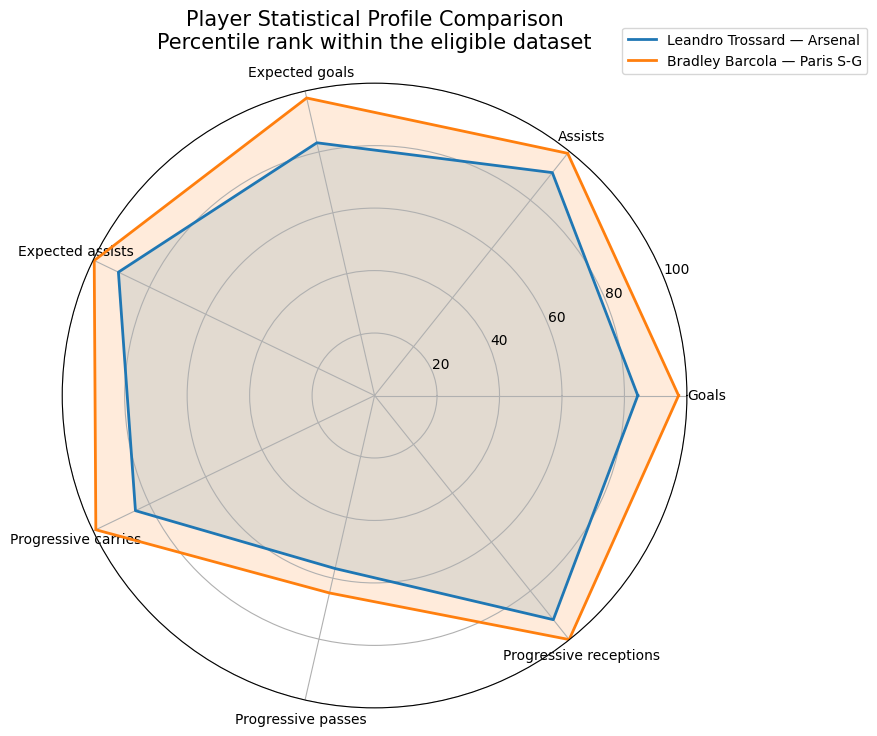

In [7]:

comparison_name = similar_players.iloc[0]["Player"]
comparison_squad = similar_players.iloc[0]["Squad"]

plot_player_radar(
    df=df_prepared,
    player_name=PLAYER_NAME,
    comparison_name=comparison_name,
    player_squad=SQUAD,
    comparison_squad=comparison_squad,
    output_path=OUTPUTS / "player_comparison_radar.png",
)

The radar automatically compares the selected player with the highest-ranked similar player. Each axis shows the player's percentile rank from 0 to 100 within the eligible dataset.

## 8. Export results

The following cell saves the raw similarity results in the `outputs/` directory.

The exported similarity score remains numeric, which makes the file easier to reuse in Excel, Python or a visualization tool.


In [8]:
OUTPUTS.mkdir(parents=True, exist_ok=True)

safe_player_name = PLAYER_NAME.casefold().replace(" ", "_")
output_path = OUTPUTS / f"similar_players_{safe_player_name}.csv"

similar_players.to_csv(output_path, index=False)

print(f"Results exported to: {output_path}")


Results exported to: C:\Users\Kevin\VScodeProjects\player-similarity-notebook\outputs\similar_players_leandro_trossard.csv


## 8. How to interpret the results

The output represents **statistical similarity**, not an absolute judgment of player quality.

Results depend on:

- the competitions and players included in the dataset;
- the minimum-minutes filter;
- the selected performance metrics;
- the season represented by the source data.

Two players can have similar profiles even if they play at different overall performance levels or in different tactical contexts.

---

## Current MVP limitations

- The model currently uses one common set of metrics for all outfield positions.
- Goalkeepers should not be compared with this version.
- Players transferred during the season may have one record per squad.
- Tactical role, league strength and team style are not yet modeled.

Future versions can add position-specific profiles, custom metric weights, filters and visual player reports.
